# Clasificacion de prestamos bancarios mediante imagenes generadas desde datos tabulares

Este notebook desarrolla un pipeline completo de ciencia de datos y aprendizaje profundo para el dataset **Bank Loan / Credit Risk**. La idea central es transformar cada registro tabular de un cliente en una imagen y entrenar una red neuronal convolucional para clasificar el resultado del prestamo.

**Objetivo predictivo:** clasificar si un prestamo pertenece a la clase `approved` (`Fully Paid`) o `not_approved` (`Charged Off`). En este contexto, `Fully Paid` se interpreta como un prestamo exitoso y `Charged Off` como un prestamo problem?tico o no recuperado.

## 1. Configuracion inicial

Se importan las librerias principales y los modulos del proyecto. El codigo esta separado en archivos `.py` para que el notebook sea legible y el proyecto sea mantenible.

In [32]:
import importlib
import data_loading
import preprocessing
import image_generation

importlib.reload(data_loading)
importlib.reload(preprocessing)
importlib.reload(image_generation)

from preprocessing import preprocess_pipeline, save_artifacts, transform_new_data
from image_generation import create_image_dataset, ImageGenerator


In [33]:
from pathlib import Path
import importlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Recargar modulos locales evita usar versiones viejas guardadas en memoria por Jupyter.
import data_loading
import preprocessing
import image_generation

importlib.reload(data_loading)
importlib.reload(preprocessing)
importlib.reload(image_generation)

from data_loading import (
    load_dataset, analyze_dataset, check_missing_values,
    check_duplicates, detect_outliers, plot_distributions, plot_correlations
)
from preprocessing import preprocess_pipeline, save_artifacts, transform_new_data
from image_generation import create_image_dataset, ImageGenerator

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

DATA_DIR = Path("data")
RESULTS_DIR = Path("results")
IMAGES_DIR = Path("images")
MODELS_DIR = Path("models")
for folder in [RESULTS_DIR, IMAGES_DIR, MODELS_DIR]:
    folder.mkdir(exist_ok=True)

TRAIN_PATH = DATA_DIR / "credit_train.csv"
NEW_USERS_PATH = DATA_DIR / "credit_test.csv"


In [34]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from data_loading import (
    load_dataset, analyze_dataset, check_missing_values,
    check_duplicates, detect_outliers, plot_distributions, plot_correlations
)
from preprocessing import preprocess_pipeline, save_artifacts, transform_new_data
from image_generation import create_image_dataset, ImageGenerator

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

DATA_DIR = Path("data")
RESULTS_DIR = Path("results")
IMAGES_DIR = Path("images")
MODELS_DIR = Path("models")
for folder in [RESULTS_DIR, IMAGES_DIR, MODELS_DIR]:
    folder.mkdir(exist_ok=True)

TRAIN_PATH = DATA_DIR / "credit_train.csv"
NEW_USERS_PATH = DATA_DIR / "credit_test.csv"

## 2. Carga y analisis del dataset

El archivo `credit_train.csv` contiene las variables explicativas y la etiqueta `Loan Status`. El archivo `credit_test.csv` no contiene etiqueta, por lo que se usa al final para simular usuarios nuevos.

Variables esperadas:
- **Numericas:** monto del prestamo, puntaje crediticio, ingreso anual, deuda mensual, historial crediticio, cuentas abiertas, saldo actual, entre otras.
- **Categoricas:** plazo, anos en el trabajo actual, propiedad de vivienda y proposito del prestamo.
- **Objetivo:** `Loan Status`, con clases `Fully Paid` y `Charged Off`.

In [35]:
df = load_dataset(TRAIN_PATH)
df.head()

Dataset cargado: data\credit_train.csv | dimensiones: (100000, 19)


,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,445412.0,Short Term,709.0,1167493.0,8 years,Home Mortgage,Home Improvements,5214.74,17.2,NaN,6.0,1.0,228190.0,416746.0,1.0,0.0
1,4771cc26-131a-45db-b5aa-537ea4ba5342,2de017a3-2e01-49cb-a581-08169e83be29,Fully Paid,262328.0,Short Term,NaN,NaN,10+ years,Home Mortgage,Debt Consolidation,33295.98,21.1,8.0,35.0,0.0,229976.0,850784.0,0.0,0.0
2,4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,Fully Paid,99999999.0,Short Term,741.0,2231892.0,8 years,Own Home,Debt Consolidation,29200.53,14.9,29.0,18.0,1.0,297996.0,750090.0,0.0,0.0
3,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,Fully Paid,347666.0,Long Term,721.0,806949.0,3 years,Own Home,Debt Consolidation,8741.90,12.0,NaN,9.0,0.0,256329.0,386958.0,0.0,0.0
4,d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,Fully Paid,176220.0,Short Term,NaN,NaN,5 years,Rent,Debt Consolidation,20639.70,6.1,NaN,15.0,0.0,253460.0,427174.0,0.0,0.0


In [36]:
numeric_cols, categorical_cols, target_col = analyze_dataset(df)


ANALISIS EXPLORATORIO DEL DATASET
Registros: 100,000
Variables: 19

Tipos de datos:
Loan ID                             str
Customer ID                         str
Loan Status                         str
Current Loan Amount             float64
Term                                str
Credit Score                    float64
Annual Income                   float64
Years in current job                str
Home Ownership                      str
Purpose                             str
Monthly Debt                    float64
Years of Credit History         float64
Months since last delinquent    float64
Number of Open Accounts         float64
Number of Credit Problems       float64
Current Credit Balance          float64
Maximum Open Credit             float64
Bankruptcies                    float64
Tax Liens                       float64
dtype: object

Columnas identificadoras excluidas del modelo: ['Loan ID', 'Customer ID']
Variable objetivo: Loan Status
Variables numericas (12): ['Current

In [37]:
missing_summary = check_missing_values(df)
duplicates = check_duplicates(df)
outliers = detect_outliers(df, numeric_cols)


VALORES NULOS
                              valores_nulos  porcentaje
Months since last delinquent          53141       53.14
Annual Income                         19154       19.15
Credit Score                          19154       19.15
Years in current job                   4222        4.22
Bankruptcies                            204        0.20
Tax Liens                                10        0.01
Maximum Open Credit                       2        0.00

Registros duplicados exactos: 10215

OUTLIERS
Current Loan Amount: 11484
Credit Score: 7115
Annual Income: 3809
Monthly Debt: 3362
Years of Credit History: 3089
Months since last delinquent: 21
Number of Open Accounts: 2283
Number of Credit Problems: 13965
Current Credit Balance: 5184
Maximum Open Credit: 5743
Bankruptcies: 11022
Tax Liens: 1928


### Visualizaciones exploratorias

Estas graficas ayudan a observar dispersion, asimetria, valores extremos y relacion entre variables numericas. Para una presentacion, son utiles para justificar la limpieza y el escalado posterior.

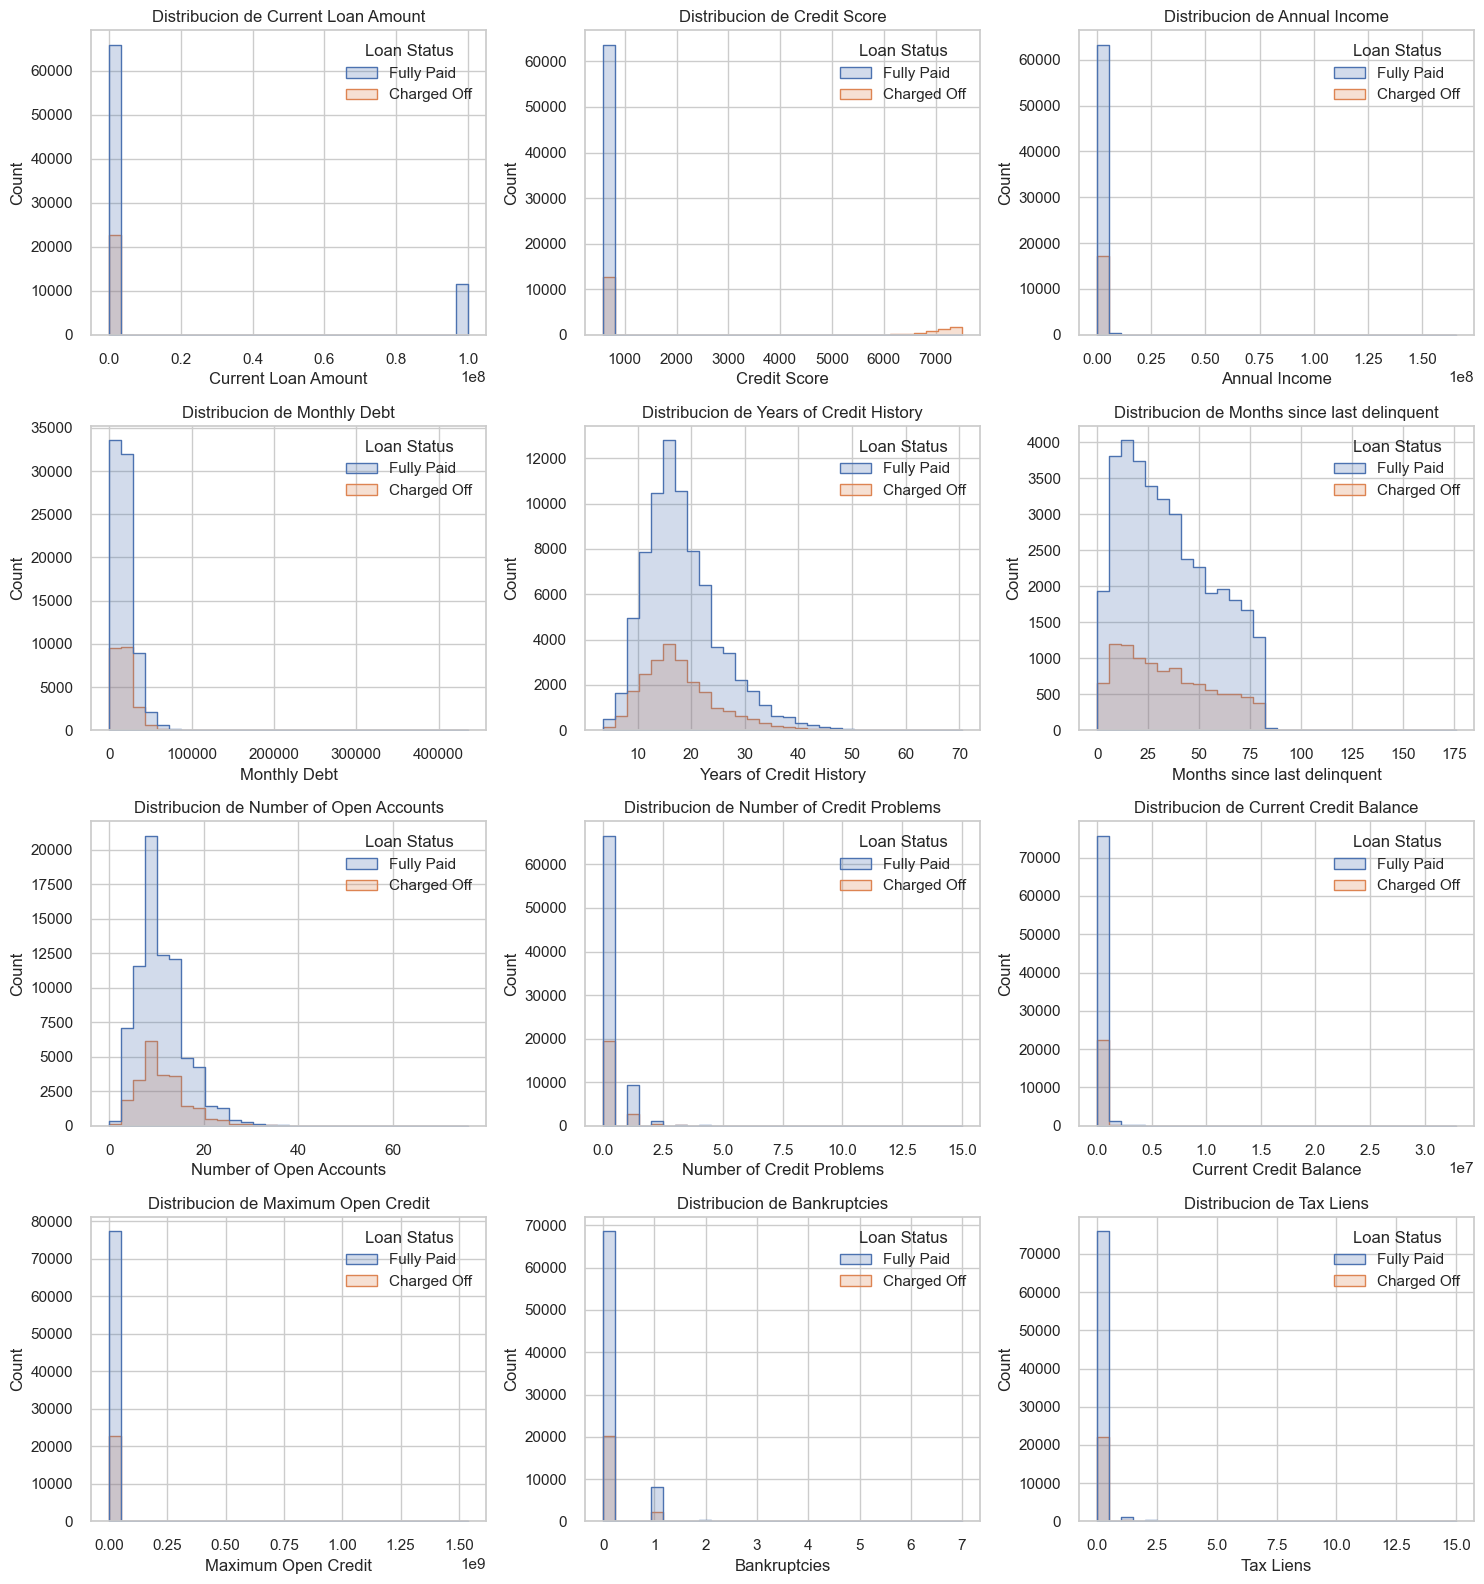

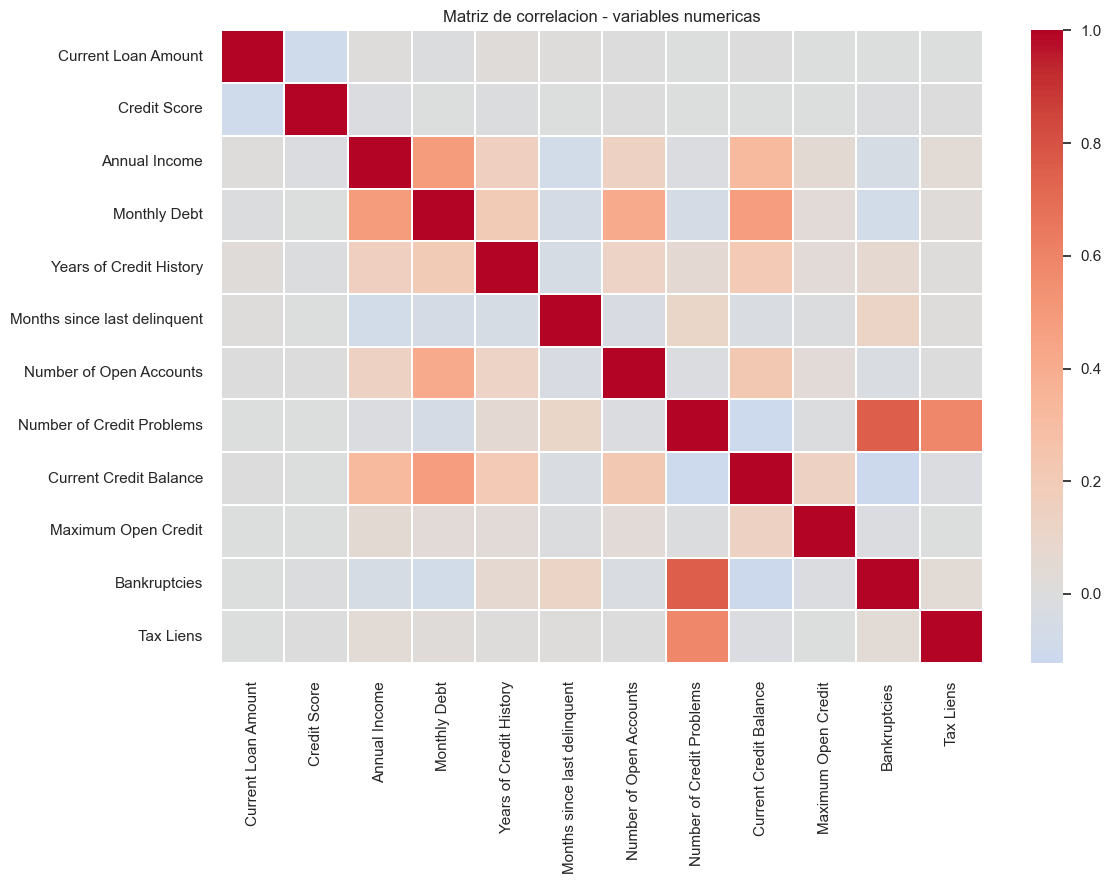

In [38]:
plot_distributions(df, numeric_cols, target_col)
corr_matrix = plot_correlations(df, numeric_cols)

## 3. Preprocesamiento

Decisiones tomadas:

- Se eliminan filas vacias y duplicados exactos.
- Se excluyen `Loan ID` y `Customer ID` porque son identificadores, no informacion generalizable. Incluirlos causaria fuga de informacion y one-hot de cardinalidad enorme.
- `Loan Status` se transforma a binario: `Fully Paid = 1` y `Charged Off = 0`.
- Las variables numericas se imputan con mediana y se escalan con `StandardScaler`.
- Las variables categoricas se imputan con moda y se codifican con `OneHotEncoder(handle_unknown='ignore')`.
- La division es estratificada para mantener la proporcion de clases en entrenamiento, validacion y prueba.

Esta correccion evita el error de memoria causado por intentar codificar columnas identificadoras con decenas de miles de valores unicos.

In [39]:
processed = preprocess_pipeline(
    df,
    numeric_cols=numeric_cols,
    categorical_cols=categorical_cols,
    target_col=target_col,
    test_size=0.15,
    val_size=0.15,
    random_state=42,
)

save_artifacts(processed["artifacts"])
processed["X_train"].head()

Filas sin etiqueta eliminadas: 0
Dataset limpio: (100000, 19) -> (89785, 19)

Division estratificada:
train: 62,849 registros | clases {1: 0.748, 0: 0.252}
val: 13,468 registros | clases {1: 0.748, 0: 0.252}
test: 13,468 registros | clases {1: 0.748, 0: 0.252}
Features finales despues de one-hot controlado: 45
Artefactos guardados en models\preprocess_artifacts.joblib


,Current Loan Amount,Credit Score,Annual Income,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,...,Purpose_Medical Bills,Purpose_Other,Purpose_Take a Trip,Purpose_major_purchase,Purpose_moving,Purpose_other,Purpose_renewable_energy,Purpose_small_business,Purpose_vacation,Purpose_wedding
0,-1.069944,-0.724539,-1.635358,-0.800876,-1.204073,-0.090438,-1.078685,-0.344387,-0.892688,-1.096194,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.919560,0.134669,0.541703,-0.621658,2.432945,-0.090438,1.279586,-0.344387,1.836968,2.401209,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,-0.609617,0.545594,0.424712,0.723500,1.286826,1.107606,0.850809,-0.344387,-0.557894,-0.495373,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.858015,-0.612469,-1.212018,-1.065585,0.736688,1.706628,0.636421,3.860857,-0.669904,-0.905139,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.235559,0.695022,-0.620176,-0.433283,1.592457,-0.090438,2.565915,-0.344387,0.343409,2.401209,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [40]:
print("Shapes finales")
print("X_train:", processed["X_train"].shape)
print("X_val:", processed["X_val"].shape)
print("X_test:", processed["X_test"].shape)
print("Primeras features:", processed["feature_names"][:10])

Shapes finales
X_train: (62849, 45)
X_val: (13468, 45)
X_test: (13468, 45)
Primeras features: ['Current Loan Amount', 'Credit Score', 'Annual Income', 'Monthly Debt', 'Years of Credit History', 'Months since last delinquent', 'Number of Open Accounts', 'Number of Credit Problems', 'Current Credit Balance', 'Maximum Open Credit']


## 4. Representacion visual de datos

Cada fila ya preprocesada se interpreta como un vector numerico. Ese vector se convierte en una imagen usando una tecnica visual.

Tecnicas implementadas:

- **RGB:** normaliza el vector a pixeles y crea tres canales con desplazamientos del mismo patron.
- **Escala de grises:** convierte directamente valores normalizados a intensidades.
- **Heatmap:** usa un mapa de color para representar magnitudes.
- **Gramian Angular Field (GAF):** transforma valores normalizados a angulos y calcula relaciones angulares entre variables.
- **Markov Transition Field (MTF):** discretiza el vector y representa transiciones entre estados.
- **Recurrence Plot:** mide similitud/distancia entre pares de posiciones del vector.

Para entrenar un clasificador claro se recomienda elegir **un metodo por experimento**. En este notebook usamos `rgb` por defecto por ser rapido y estable para demostracion.

Generando 2,000 imagenes | metodo=rgb | split=train
  1,000/2,000
  2,000/2,000
Generando 2,000 imagenes | metodo=rgb | split=val
  1,000/2,000
  2,000/2,000
Generando 2,000 imagenes | metodo=rgb | split=test
  1,000/2,000
  2,000/2,000


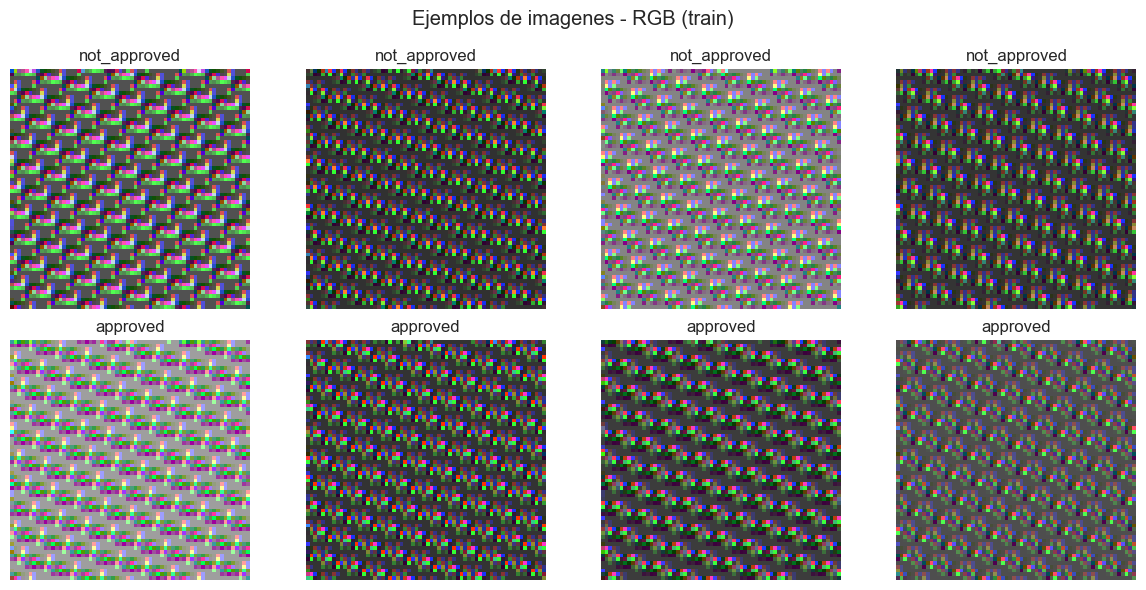


Estructura creada:
images/rgb/train/not_approved y approved
images/rgb/val/not_approved y approved
images/rgb/test/not_approved y approved


{'train': WindowsPath('images/rgb/train'),
 'val': WindowsPath('images/rgb/val'),
 'test': WindowsPath('images/rgb/test')}

In [41]:
METHOD = "rgb"
IMAGE_SIZE = (64, 64)

# Para una demo rapida se puede limitar el numero de imagenes por split.
# Para el experimento completo, cambia MAX_SAMPLES_PER_SPLIT = None.
MAX_SAMPLES_PER_SPLIT = 2000

image_paths = create_image_dataset(
    processed["X_train"], processed["X_val"], processed["X_test"],
    processed["y_train"], processed["y_val"], processed["y_test"],
    image_size=IMAGE_SIZE,
    method=METHOD,
    save_dir=IMAGES_DIR,
    max_samples_per_split=MAX_SAMPLES_PER_SPLIT,
)
image_paths

### Ejemplos de diferentes representaciones

La siguiente celda toma un registro y muestra como cambia su representacion visual segun el metodo. Esto es valioso para explicar la etapa de conversion tabular a imagen.

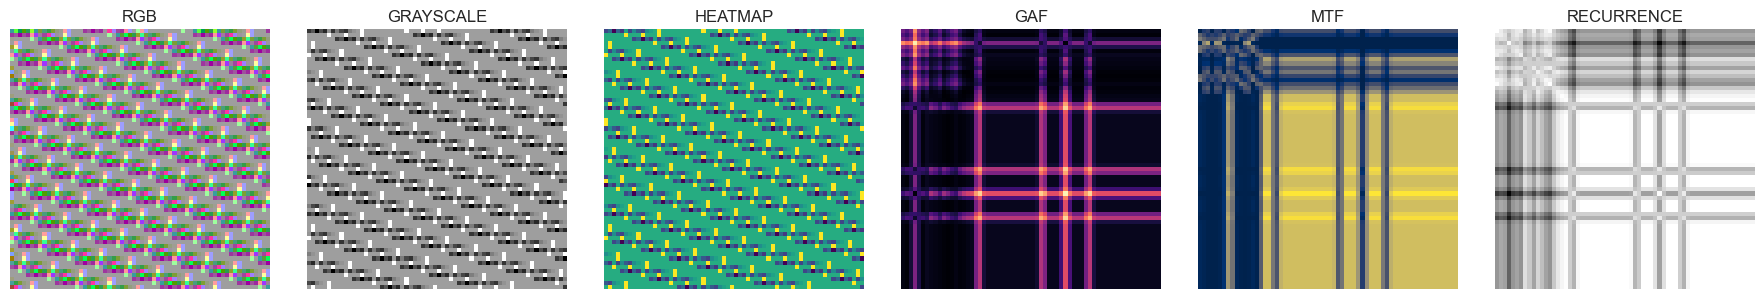

In [28]:
generator = ImageGenerator(image_size=IMAGE_SIZE, save_dir=IMAGES_DIR)
sample_vector = processed["X_train"].iloc[0].to_numpy()
methods = ["rgb", "grayscale", "heatmap", "gaf", "mtf", "recurrence"]

fig, axes = plt.subplots(1, len(methods), figsize=(18, 3))
for ax, method in zip(axes, methods):
    img = generator.generate_image(sample_vector, method)
    ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
    ax.set_title(method.upper())
    ax.axis("off")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "visual_methods_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

## 5. Entrenamiento del modelo CNN

La arquitectura base contiene:

- Bloques `Conv2D` para extraer patrones locales de las imagenes.
- `BatchNormalization` para estabilizar el entrenamiento.
- `MaxPooling2D` para reducir dimensionalidad espacial.
- `Dropout` para reducir sobreajuste.
- `GlobalAveragePooling2D` para resumir mapas de activacion.
- Capa densa final con `softmax` para clasificacion binaria con dos neuronas.

Funcion de perdida: `categorical_crossentropy`.
Optimizador: `Adam`.
Metrica durante entrenamiento: `accuracy`.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,914 (433.26 KB)

 Trainable params: 110,466 (431.51 KB)

 Non-trainable params: 448 (1.75 KB)

Modelo compilado: Adam + categorical_crossentropy + accuracy
Found 2000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.
Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 170ms/step - accuracy: 0.7060 - loss: 0.6325 - val_accuracy: 0.7550 - val_loss: 0.5986 - learning_rate: 0.0010
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 158ms/step - accuracy: 0.7295 - loss: 0.5870 - val_accuracy: 0.2810 - val_loss: 0.7701 - learning_rate: 0.0010
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 166ms/step - accuracy: 0.7510 - loss: 0.5576 - val_accuracy: 0.2450 - val_loss: 1.0503 - learning_rate: 0.0010
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 159ms/step - accuracy: 0.7775 - loss: 0.5025 - val_accuracy: 0.2460 - val_loss: 1.3427 - learning_rate: 5.0000e-04
Mejor modelo guardado en models\best_rgb_cnn.keras


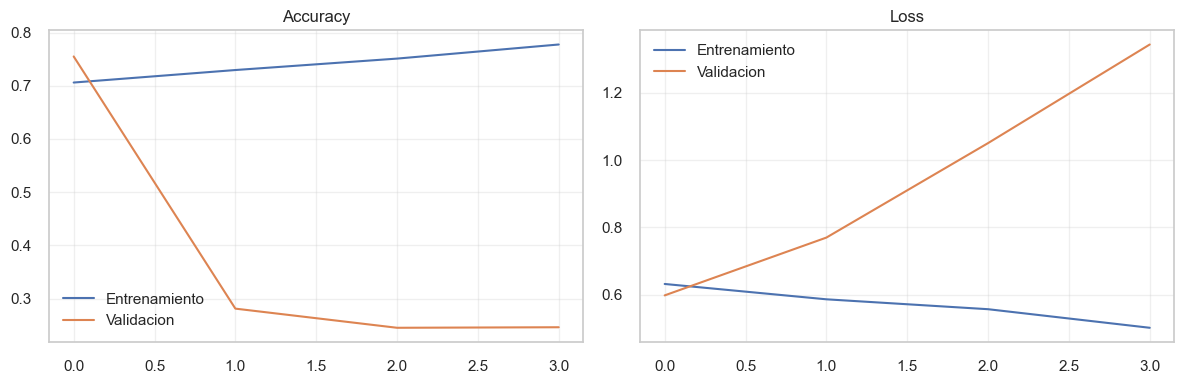

In [42]:
# Ejecuta esta celda cuando ya existan imagenes en images/rgb/train y images/rgb/val.
# Si tu computador es lento, empieza con epochs=3 y batch_size=32.

from model import CNNModel

cnn = CNNModel(input_shape=IMAGE_SIZE + (3,), model_type="custom_cnn")
cnn.summary()
cnn.compile_model(learning_rate=1e-3)

history = cnn.train_model(
    train_dir=IMAGES_DIR / METHOD / "train",
    val_dir=IMAGES_DIR / METHOD / "val",
    epochs=5,
    batch_size=32,
    patience=3,
    save_path=MODELS_DIR / f"best_{METHOD}_cnn.keras",
)
cnn.plot_training_history(RESULTS_DIR / f"training_history_{METHOD}.png")

## 6. Evaluacion del desempeno

Se reportan metricas clasicas de clasificacion:

- **Accuracy:** porcentaje total de aciertos.
- **Precision:** de las predicciones de una clase, cuantas fueron correctas.
- **Recall:** de los casos reales de una clase, cuantos fueron encontrados.
- **F1-score:** balance entre precision y recall.
- **Matriz de confusion:** distribucion de aciertos y errores por clase.

En prestamos bancarios, los falsos positivos pueden ser costosos si el sistema aprueba clientes que terminan en incumplimiento. Por eso precision y matriz de confusion son especialmente importantes.

Found 2000 files belonging to 2 classes.

Metricas principales
accuracy: 0.7345
precision: 0.5395
recall: 0.7345
f1_score: 0.6221

Reporte por clase
              precision    recall  f1-score   support

    approved       0.73      1.00      0.85      1469
not_approved       0.00      0.00      0.00       531

    accuracy                           0.73      2000
   macro avg       0.37      0.50      0.42      2000
weighted avg       0.54      0.73      0.62      2000



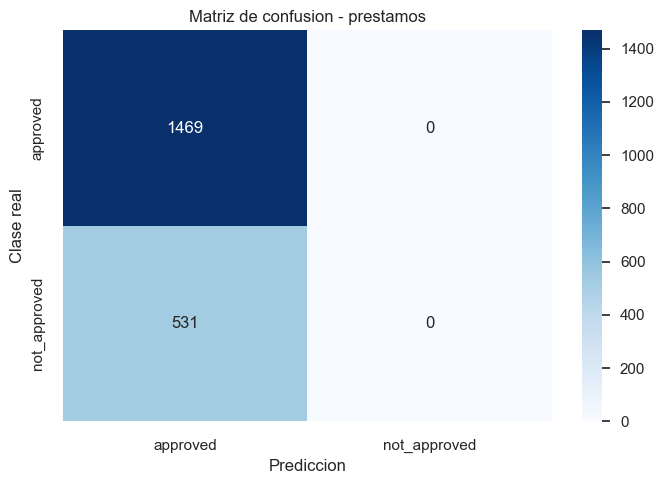


Interpretacion academica y de negocio
Accuracy indica la proporcion total de solicitudes correctamente clasificadas: 73.5%.
Precision mide cuantas aprobaciones/rechazos predichos son confiables: 53.9%.
Recall mide cuantas solicitudes de cada clase logra recuperar el modelo: 73.5%.
F1-score resume el equilibrio entre precision y recall: 62.2%.
En prestamos, los falsos positivos son delicados: aprobar clientes que terminan en incumplimiento puede generar perdida financiera.

Pruebas simuladas con registros de test
Prueba 1: prediccion=approved | confianza=61.4% | real=not_approved
Prueba 2: prediccion=approved | confianza=61.7% | real=approved
Prueba 3: prediccion=approved | confianza=62.0% | real=approved
Prueba 4: prediccion=approved | confianza=61.4% | real=approved
Prueba 5: prediccion=approved | confianza=61.6% | real=approved


{'accuracy': 0.7345,
 'precision': 0.5394902500000001,
 'recall': 0.7345,
 'f1_score': 0.6220700490054771}

In [43]:
from evaluation import evaluate_model_performance

metrics = evaluate_model_performance(
    cnn.model,
    test_dir=IMAGES_DIR / METHOD / "test",
    input_shape=IMAGE_SIZE + (3,),
    batch_size=32,
)
metrics

## 7. Pruebas con usuarios nuevos

`credit_test.csv` no tiene `Loan Status`, por lo que representa un escenario realista: llegan solicitudes nuevas y el modelo debe predecir una probabilidad. La siguiente celda toma registros nuevos, aplica el mismo preprocesamiento, genera imagenes temporales y produce predicciones.

In [44]:
new_users = load_dataset(NEW_USERS_PATH)
new_users_sample = new_users.head(5)
X_new = transform_new_data(new_users_sample, processed["artifacts"])

predictions = []
for i, row in X_new.iterrows():
    img = generator.generate_image(row.to_numpy(), METHOD)
    img_path = RESULTS_DIR / f"new_user_{i:02d}.png"
    generator.save_image(img, img_path)
    pred = cnn.predict_image(img_path)
    predictions.append({
        "registro": i,
        "prediccion": pred["class_name"],
        "confianza": pred["confidence"],
        "loan_id": new_users_sample.iloc[i].get("Loan ID", None),
    })

pd.DataFrame(predictions)

Dataset cargado: data\credit_test.csv | dimensiones: (10000, 18)


,registro,prediccion,confianza,loan_id
0,0,approved,0.626818,f738779f-c726-40dc-92cf-689d73af533d
1,1,approved,0.624327,6dcc0947-164d-476c-a1de-3ae7283dde0a
2,2,approved,0.613699,f7744d01-894b-49c3-8777-fc6431a2cff1
3,3,approved,0.620932,83721ffb-b99a-4a0f-aea5-ef472a138b41
4,4,approved,0.626436,08f3789f-5714-4b10-929d-e1527ab5e5a3


## 8. Ventajas, limitaciones y conclusiones

**Ventajas del enfoque basado en imagenes:**

- Permite usar CNN, transfer learning y tecnicas visuales sobre datos originalmente tabulares.
- Las representaciones GAF, MTF y recurrence capturan relaciones entre variables como patrones espaciales.
- Facilita una demostracion visual atractiva para presentacion academica.

**Limitaciones:**

- Convertir tablas a imagenes puede introducir perdida o distorsion de informacion.
- Modelos tabulares clasicos como Random Forest, XGBoost o redes MLP podrian ser mas eficientes.
- La interpretabilidad financiera requiere cuidado: una imagen generada no equivale a causalidad.
- Si se generan demasiadas imagenes, el costo de almacenamiento y entrenamiento aumenta.

**Conclusion:**

El proyecto implementa un pipeline completo: carga, EDA, limpieza, preprocesamiento, transformacion visual, generacion automatica de dataset de imagenes, entrenamiento CNN, evaluacion con metricas y simulacion de nuevos usuarios. El flujo queda listo para demostracion universitaria y puede ampliarse comparando metodos visuales o arquitecturas como MobileNet, EfficientNet y ResNet.

**Mejoras futuras:**

1. Comparar `rgb`, `gaf`, `mtf` y `recurrence` con las mismas particiones.
2. Ajustar hiperparametros y balancear clases si el recall de `not_approved` es bajo.
3. Comparar contra modelos tabulares tradicionales como baseline.
4. Agregar interpretabilidad con Grad-CAM sobre imagenes y SHAP sobre variables originales.